In [9]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as patches

In [3]:
def sci_notation_no_sigfigs(number, pos):
    a, b = f"{number:.0e}".split("e")
    b = int(b)
    if b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"


def sci_notation_one_sigfig(number, pos):
    a, b = f"{number:.1e}".split("e")
    b = int(b)
    if b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"

<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:14: SyntaxWarning: invalid escape sequence '\,'
/var/folders/s9/bht_sc9n7ys6m0q3h_3htntc0000gn/T/ipykernel_25395/2028218832.py:6: SyntaxWarning: invalid escape sequence '\,'
  return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"
/var/folders/s9/bht_sc9n7ys6m0q3h_3htntc0000gn/T/ipykernel_25395/2028218832.py:6: SyntaxWarning: invalid escape sequence '\,'
  return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"
/var/folders/s9/bht_sc9n7ys6m0q3h_3htntc0000gn/T/ipykernel_25395/2028218832.py:14: SyntaxWarning: invalid escape sequence '\,'
  return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"
/var/folders/s9/bht_sc9n7ys6m0q3h_3htntc0000gn/T/ipykernel_25395/20282188

In [18]:
INDEX_SHIFT = 1
active_site_residues = [
    (41, 41),
    (49, 49),
    (143, 145),
    (163, 167),
    (187, 192),
]

covariance_matrix = np.load("./covariance_matrices/cov_xtal_ensemble.npy")

0.18131864704028616
(41, 41)
(49, 49)
(143, 145)
(163, 167)
(187, 192)


<>:37: SyntaxWarning: invalid escape sequence '\A'
<>:37: SyntaxWarning: invalid escape sequence '\A'
/var/folders/s9/bht_sc9n7ys6m0q3h_3htntc0000gn/T/ipykernel_25395/302567100.py:37: SyntaxWarning: invalid escape sequence '\A'
  cbar.set_label('Isotropic Cov. ($\AA^2$)', rotation=270, labelpad=15)


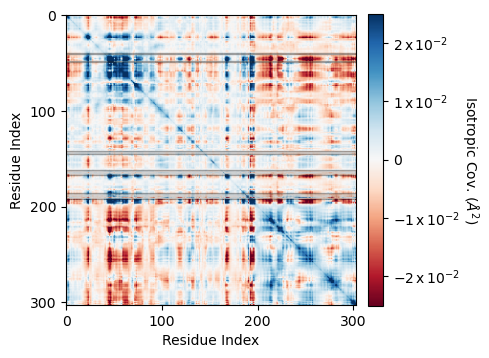

In [25]:
ticks = np.arange(0, covariance_matrix.shape[1], 100)
cmap = 'RdBu'


# how much to zoom colorbar
scale = 0.025

figsize = (5,5)

fig = plt.figure(figsize=figsize)
ax1 = plt.subplot(111)

# ax1.set_title(covariance_matrix[0], 
#                 fontweight='bold', fontsize=10)


print(covariance_matrix.max())
im = ax1.imshow(
    covariance_matrix,
    cmap=cmap, 
    vmin=-scale,
    vmax=scale,
)

ax1.set_xticks(ticks)
ax1.set_xticklabels([str(int(t)) for t in ticks])
ax1.set_yticks(ticks)
ax1.set_yticklabels([str(int(t)) for t in ticks])
ax1.set_xlabel('Residue Index')
ax1.set_ylabel('Residue Index')

# ax1.set_xticks([])
# ax1.set_yticks([])

cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, format=FuncFormatter(sci_notation_no_sigfigs))

cbar.set_label('Isotropic Cov. ($\AA^2$)', rotation=270, labelpad=15)

for residue_range in active_site_residues:
    print(residue_range)
    rect = patches.Rectangle(
        ( -0.5, residue_range[0] - 0.5 - INDEX_SHIFT ),
        width=covariance_matrix.shape[1],
        height=residue_range[1] - residue_range[0] + 1,
        linewidth=1,
        edgecolor='black',
        facecolor='grey',
        alpha=0.3
    )
    ax1.add_patch(rect)


plt.tight_layout()
plt.savefig("./figures/highlighted_covariance_matrix.png")
plt.show()